In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.metrics import pairwise_distances

np.random.seed(0)

In [ ]:
data = fetch_california_housing()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="HouseValue")

In [ ]:
# TASK 1

# Combined DataFrame view
df = pd.concat([X, y], axis=1)

# Shape
print("Features (X) Shape:", X.shape)
print("Target (y) Shape:", y.shape)

# Column Names
print("\nFeature Column Names:")
print(list(X.columns))
print("Target Name:", y.name)

# Data Types and Non-Null Info
print("\nFeature Summary & Info:")
print(X.info())

# Summary Statistics
print("\nFeature Summary Statistics:")
print(X.describe().T)

# Preview First 5 Rows
print("\nFirst 5 Rows of Features (X):")
print(X.head())

print("\nFirst 5 Values of Target (y):")
print(y.head())

Features (X) Shape: (20640, 8)
Target (y) Shape: (20640,)

Feature Column Names:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target Name: HouseValue

Feature Summary & Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB
None

Feature Summary Statistics:
              count         mean          std         min         25%  \
MedInc      20640.0     3.870671     1.899822    0.499900    2.563400   
HouseAge    20640.0    28.639486 

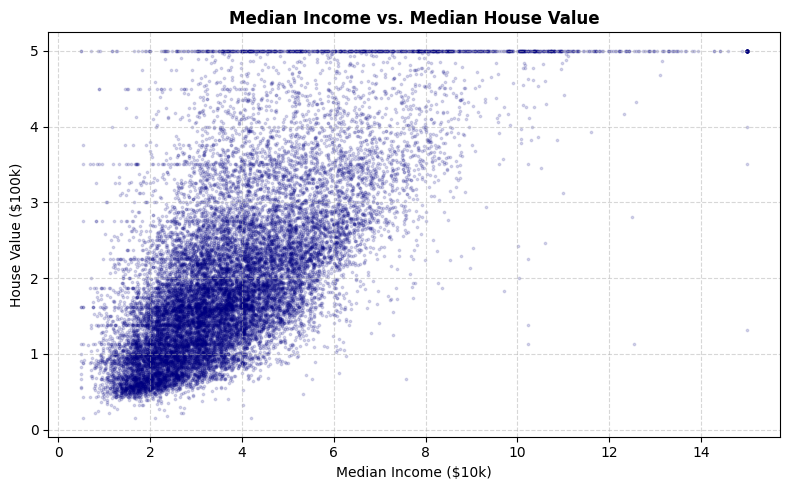

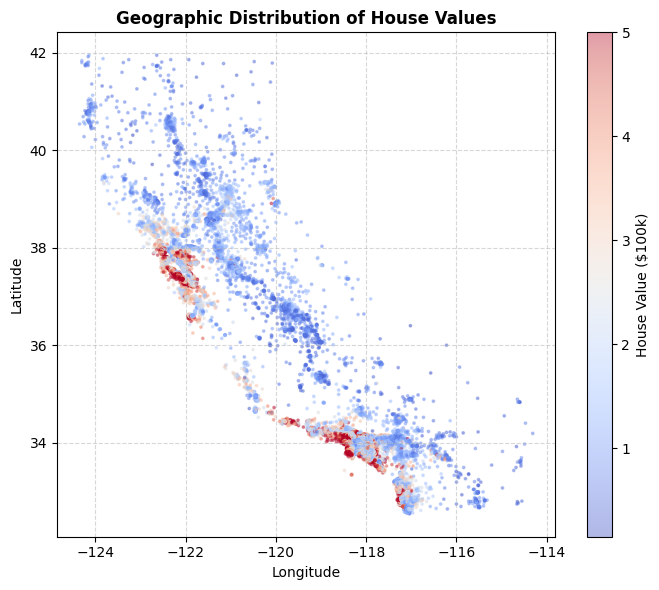

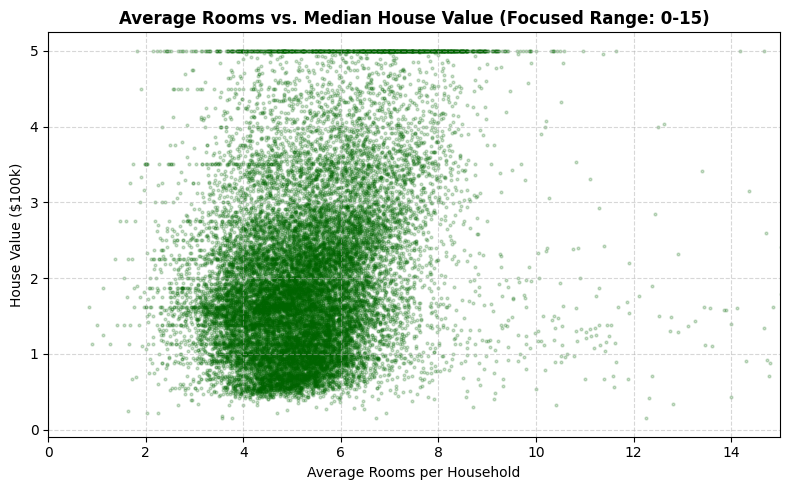

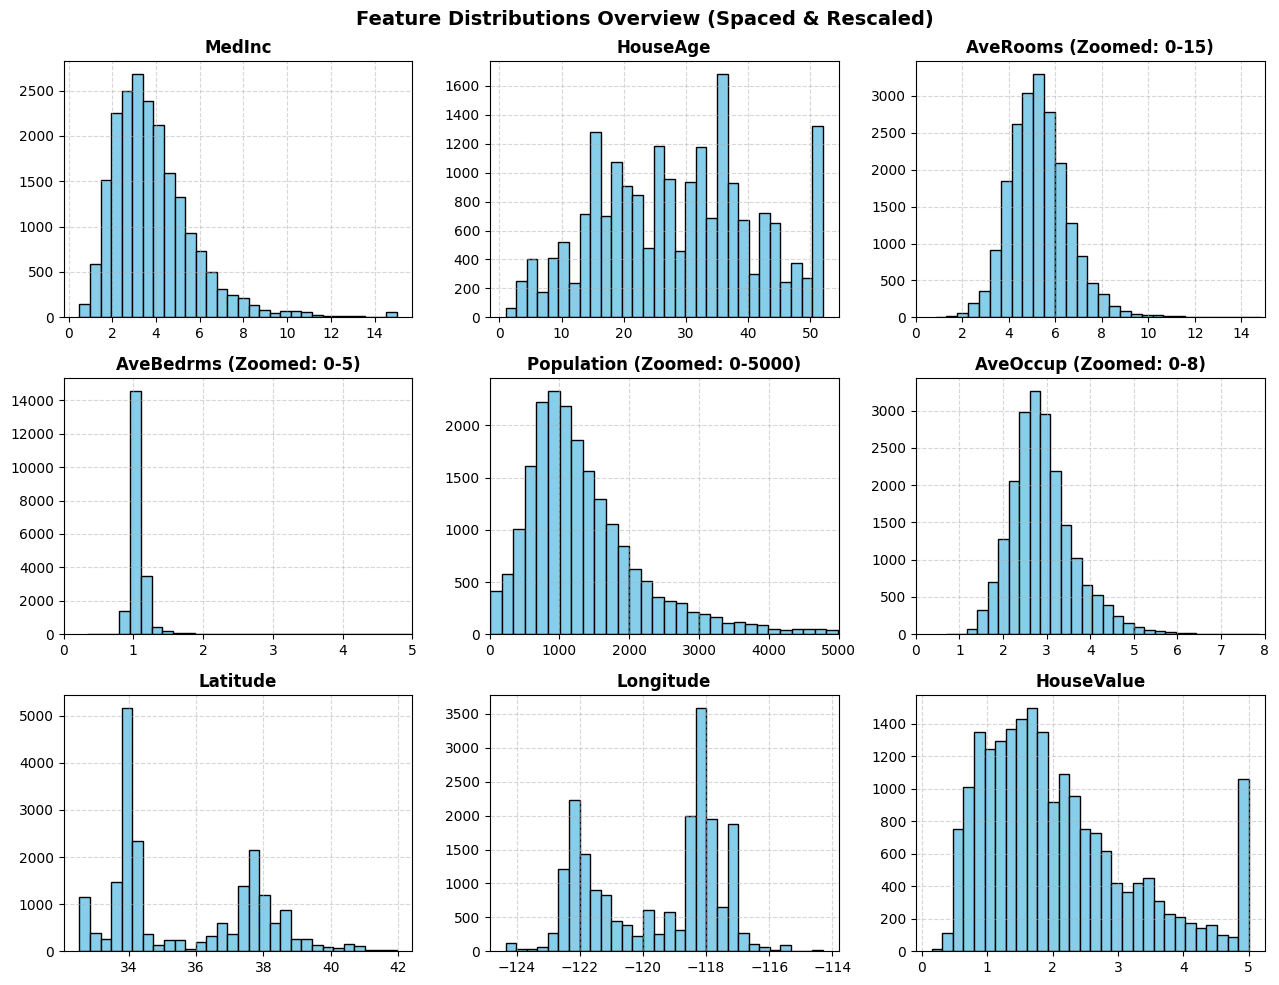

In [ ]:
import os
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import fetch_california_housing

os.makedirs("figs", exist_ok=True)

housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = pd.Series(housing.target, name="HouseValue")
df = pd.concat([X, y], axis=1)

# Plot 1: Income vs. House Value (Smaller points, lighter alpha)
plt.figure(figsize=(8, 5))
plt.scatter(df["MedInc"], df["HouseValue"], alpha=0.15, s=3, color="navy")
plt.title("Median Income vs. Median House Value", fontsize=12, fontweight="bold")
plt.xlabel("Median Income ($10k)", fontsize=10)
plt.ylabel("House Value ($100k)", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("figs/1_income_vs_value.png", dpi=300)
plt.show()

# Plot 2: Geographic Distribution (Balanced aspect ratio)
plt.figure(figsize=(7, 6))
scatter = plt.scatter(
    df["Longitude"],
    df["Latitude"],
    c=df["HouseValue"],
    cmap="coolwarm",
    s=3,
    alpha=0.4
)
plt.colorbar(scatter, label="House Value ($100k)")
plt.title("Geographic Distribution of House Values", fontsize=12, fontweight="bold")
plt.xlabel("Longitude", fontsize=10)
plt.ylabel("Latitude", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("figs/2_geographic_distribution.png", dpi=300)
plt.show()

# Plot 3: Average Rooms vs. House Value (Focused View: 0 to 15 rooms)
plt.figure(figsize=(8, 5))
plt.scatter(df["AveRooms"], df["HouseValue"], alpha=0.2, s=4, color="darkgreen")
plt.xlim(0, 15)  # Focuses on main data bulk without removing raw points from df
plt.title("Average Rooms vs. Median House Value (Focused Range: 0-15)", fontsize=12, fontweight="bold")
plt.xlabel("Average Rooms per Household", fontsize=10)
plt.ylabel("House Value ($100k)", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("figs/3_rooms_vs_value.png", dpi=300)
plt.show()

# 3. Initialize 3x3 subplot grid
fig, axes = plt.subplots(3, 3, figsize=(13, 10))
axes = axes.flatten()

# Define custom display ranges for heavily skewed variables
x_limits = {
    "AveRooms": (0, 15),
    "AveBedrms": (0, 5),
    "Population": (0, 5000),
    "AveOccup": (0, 8),
}

# 4. Plot each feature and target
for idx, col in enumerate(df.columns):
    ax = axes[idx]

    if col in x_limits:
        # Filter within display range for clean, visible bins
        low, high = x_limits[col]
        filtered_data = df[col][(df[col] >= low) & (df[col] <= high)]
        ax.hist(filtered_data, bins=30, color="skyblue", edgecolor="black")
        ax.set_xlim(low, high)
        ax.set_title(f"{col} (Zoomed: {low}-{high})", fontweight="bold")
    else:
        ax.hist(df[col], bins=30, color="skyblue", edgecolor="black")
        ax.set_title(col, fontweight="bold")

    ax.grid(True, linestyle="--", alpha=0.5)

# 5. Format layout and save
plt.suptitle(
    "Feature Distributions Overview (Spaced & Rescaled)",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.savefig("figs/1_feature_histograms_spaced.png", dpi=300)
plt.show()

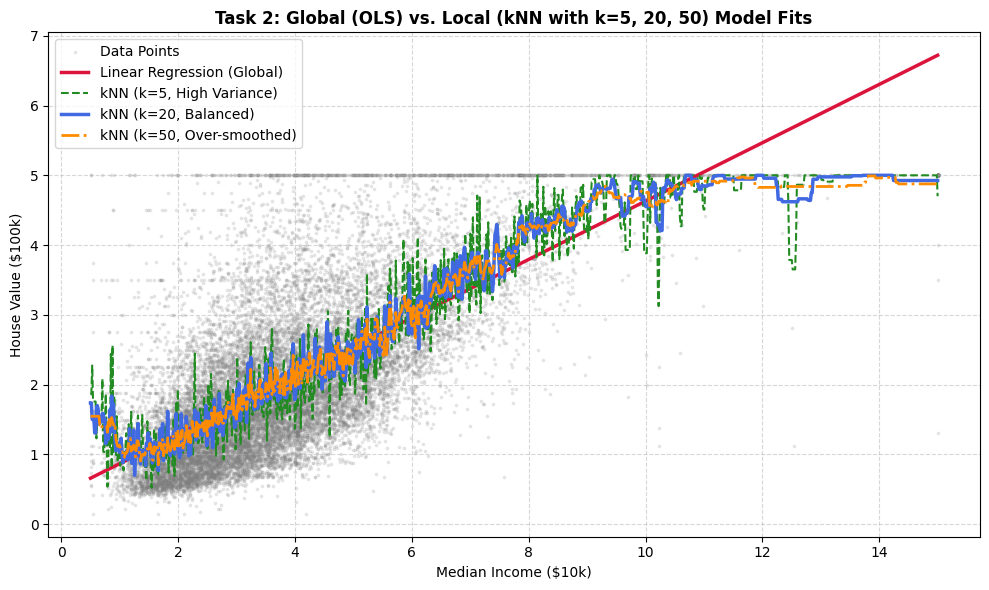

In [ ]:
# 1. Select 1D feature (MedInc) and target
X_1d = X[["MedInc"]].values
y_val = y.values

# 2. Fit Global Model (OLS) and Local Models (kNN with k=5, 20, 50)
lin_reg = LinearRegression().fit(X_1d, y_val)
knn_5 = KNeighborsRegressor(n_neighbors=5).fit(X_1d, y_val)
knn_20 = KNeighborsRegressor(n_neighbors=20).fit(X_1d, y_val)
knn_50 = KNeighborsRegressor(n_neighbors=50).fit(X_1d, y_val)

# 3. Predict across a continuous input line
X_grid = np.linspace(X_1d.min(), X_1d.max(), 1000).reshape(-1, 1)
y_pred_ols = lin_reg.predict(X_grid)
y_pred_knn_5 = knn_5.predict(X_grid)
y_pred_knn_20 = knn_20.predict(X_grid)
y_pred_knn_50 = knn_50.predict(X_grid)

# 4. Plot prediction curves comparing all 4 models
plt.figure(figsize=(10, 6))
plt.scatter(X_1d, y_val, alpha=0.15, s=3, color="gray", label="Data Points")

plt.plot(
    X_grid,
    y_pred_ols,
    color="crimson",
    linewidth=2.5,
    label="Linear Regression (Global)",
)
plt.plot(
    X_grid,
    y_pred_knn_5,
    color="forestgreen",
    linewidth=1.5,
    linestyle="--",
    label="kNN (k=5, High Variance)",
)
plt.plot(
    X_grid,
    y_pred_knn_20,
    color="royalblue",
    linewidth=2.5,
    label="kNN (k=20, Balanced)",
)
plt.plot(
    X_grid,
    y_pred_knn_50,
    color="darkorange",
    linewidth=2.0,
    linestyle="-.",
    label="kNN (k=50, Over-smoothed)",
)

plt.title(
    "Task 2: Global (OLS) vs. Local (kNN with k=5, 20, 50) Model Fits",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Median Income ($10k)", fontsize=10)
plt.ylabel("House Value ($100k)", fontsize=10)
plt.legend(frameon=True)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("figs/2_ols_vs_knn_multi_k.png", dpi=300)
plt.show()

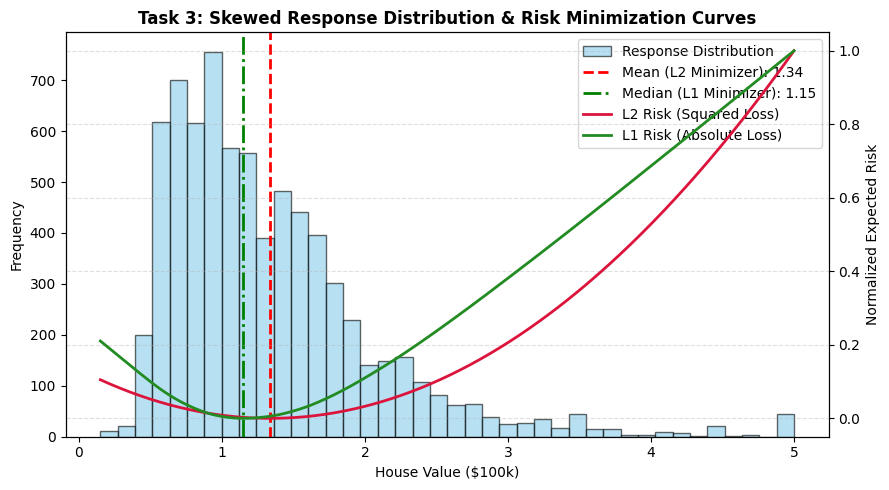

In [ ]:
# TASK 3

# 1. Select a skewed subset (e.g., lower income bracket where values are heavily skewed)
subset = df[df["MedInc"] < 3.0]["HouseValue"].values

# Calculate summary statistics
y_mean = np.mean(subset)
y_median = np.median(subset)

# 2. Compute Risk Curves (Expected Loss across candidate predictions c)
c_vals = np.linspace(subset.min(), subset.max(), 500)
l2_risk = [np.mean((subset - c) ** 2) for c in c_vals]  # Mean Squared Error
l1_risk = [np.mean(np.abs(subset - c)) for c in c_vals]  # Mean Absolute Error

# Normalize risk curves for comparison on the same scale
l2_risk_norm = (l2_risk - np.min(l2_risk)) / (np.max(l2_risk) - np.min(l2_risk))
l1_risk_norm = (l1_risk - np.min(l1_risk)) / (np.max(l1_risk) - np.min(l1_risk))

# 3. Plot Response Distribution and Risk Curves
fig, ax1 = plt.subplots(figsize=(9, 5))

# Plot Histogram on Left Axis
ax1.hist(
    subset,
    bins=40,
    color="skyblue",
    edgecolor="black",
    alpha=0.6,
    label="Response Distribution",
)
ax1.set_xlabel("House Value ($100k)", fontsize=10)
ax1.set_ylabel("Frequency", fontsize=10)

# Vertical lines for Mean and Median
ax1.axvline(
    y_mean,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean (L2 Minimizer): {y_mean:.2f}",
)
ax1.axvline(
    y_median,
    color="green",
    linestyle="-.",
    linewidth=2,
    label=f"Median (L1 Minimizer): {y_median:.2f}",
)

# Plot Normalized Risk Curves on Right Axis
ax2 = ax1.twinx()
ax2.plot(
    c_vals,
    l2_risk_norm,
    color="crimson",
    linewidth=2,
    label="L2 Risk (Squared Loss)",
)
ax2.plot(
    c_vals,
    l1_risk_norm,
    color="forestgreen",
    linewidth=2,
    label="L1 Risk (Absolute Loss)",
)
ax2.set_ylabel("Normalized Expected Risk", fontsize=10)

# Format Title and Legends
plt.title(
    "Task 3: Skewed Response Distribution & Risk Minimization Curves",
    fontsize=12,
    fontweight="bold",
)
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper right")

plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("figs/3_risk_curves.png", dpi=300)
plt.show()

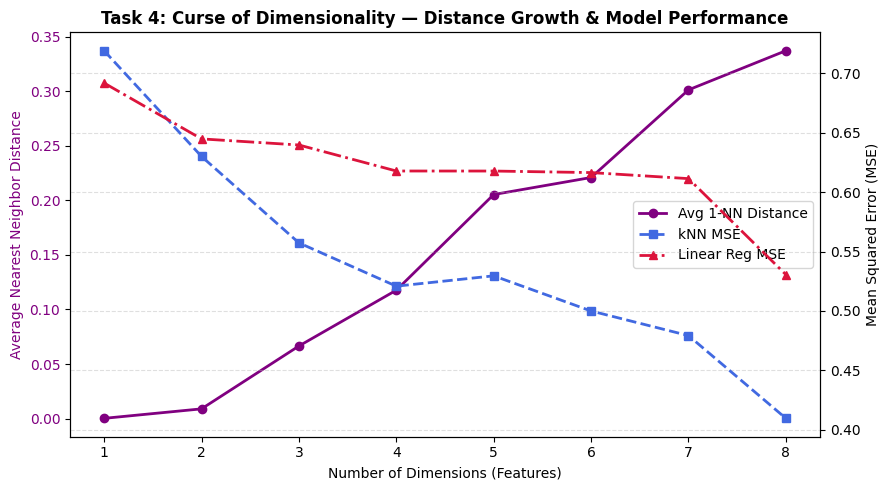

In [ ]:
# TASK 4

from sklearn.preprocessing import StandardScaler

# Standardize features for accurate distance calculations in higher dimensions
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

dims = range(1, X_scaled.shape[1] + 1)
avg_distances = []
knn_mses = []
lr_mses = []

# Iteratively increase dimensions by adding features one by one
for d in dims:
    X_tr = X_train[:, :d]
    X_te = X_test[:, :d]

    # 1. Fit kNN (k=15)
    knn = KNeighborsRegressor(n_neighbors=15).fit(X_tr, y_train)
    y_pred_knn = knn.predict(X_te)
    knn_mses.append(mean_squared_error(y_test, y_pred_knn))

    # 2. Fit Linear Regression
    lr = LinearRegression().fit(X_tr, y_train)
    y_pred_lr = lr.predict(X_te)
    lr_mses.append(mean_squared_error(y_test, y_pred_lr))

    # 3. Calculate mean distance to the single nearest neighbor
    distances, _ = knn.kneighbors(X_te, n_neighbors=1)
    avg_distances.append(np.mean(distances))

# Plot Results: Distance Decay and Model Error
fig, ax1 = plt.subplots(figsize=(9, 5))

# Distance curve (Left axis)
ax1.plot(
    dims,
    avg_distances,
    color="purple",
    marker="o",
    linewidth=2,
    label="Avg 1-NN Distance",
)
ax1.set_xlabel("Number of Dimensions (Features)", fontsize=10)
ax1.set_ylabel("Average Nearest Neighbor Distance", color="purple", fontsize=10)
ax1.tick_params(axis="y", labelcolor="purple")

# Error curves (Right axis)
ax2 = ax1.twinx()
ax2.plot(
    dims,
    knn_mses,
    color="royalblue",
    marker="s",
    linewidth=2,
    linestyle="--",
    label="kNN MSE",
)
ax2.plot(
    dims,
    lr_mses,
    color="crimson",
    marker="^",
    linewidth=2,
    linestyle="-.",
    label="Linear Reg MSE",
)
ax2.set_ylabel("Mean Squared Error (MSE)", color="black", fontsize=10)

plt.title(
    "Task 4: Curse of Dimensionality — Distance Growth & Model Performance",
    fontsize=12,
    fontweight="bold",
)

# Merge legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="center right")

plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("figs/4_curse_of_dimensionality.png", dpi=300)
plt.show()

OLS Test MSE: 0.5306
Ridge (L2) Test MSE: 0.5292
Lasso (L1) Test MSE: 0.5984


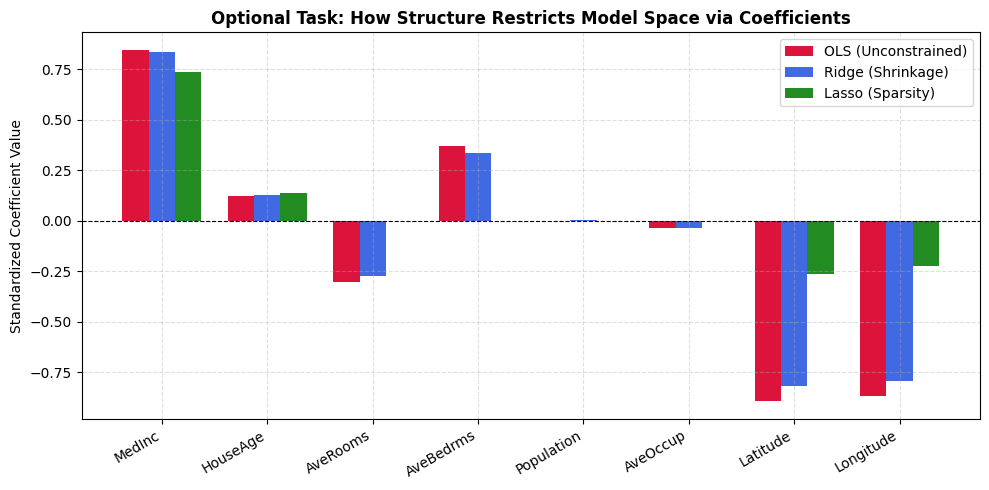

In [ ]:
# OPTIONAL TASK

from sklearn.linear_model import Lasso, LinearRegression, Ridge

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

# 2. Fit Models
ols = LinearRegression().fit(X_train, y_train)
ridge = Ridge(alpha=100.0).fit(X_train, y_train)
lasso = Lasso(alpha=0.05).fit(X_train, y_train)

models = {"OLS": ols, "Ridge (L2)": ridge, "Lasso (L1)": lasso}

# Compute Test MSE
for name, model in models.items():
    mse = mean_squared_error(y_test, model.predict(X_test))
    print(f"{name} Test MSE: {mse:.4f}")

# 3. Plot 1: Coefficient Profile Comparison
fig, ax = plt.subplots(figsize=(10, 5))
x_indices = np.arange(len(housing.feature_names))
width = 0.25

ax.bar(
    x_indices - width,
    ols.coef_,
    width,
    label="OLS (Unconstrained)",
    color="crimson",
)
ax.bar(
    x_indices,
    ridge.coef_,
    width,
    label="Ridge (Shrinkage)",
    color="royalblue",
)
ax.bar(
    x_indices + width,
    lasso.coef_,
    width,
    label="Lasso (Sparsity)",
    color="forestgreen",
)

ax.set_xticks(x_indices)
ax.set_xticklabels(housing.feature_names, rotation=30, ha="right")
ax.set_ylabel("Standardized Coefficient Value", fontsize=10)
ax.set_title(
    "Optional Task: How Structure Restricts Model Space via Coefficients",
    fontsize=12,
    fontweight="bold",
)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("figs/5_structured_coefficients.png", dpi=300)
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import QuantileTransformer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import RidgeCV
from sklearn.cluster import MiniBatchKMeans
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Base Setup
X_train_df = pd.DataFrame(X_train, columns=['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']).copy()
X_test_df = pd.DataFrame(X_test, columns=['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']).copy()
y_train_series = pd.Series(np.ravel(y_train), index=X_train_df.index)

# 2. Rotations & Essential Ratios
for df in [X_train_df, X_test_df]:
    for angle in [15, 30, 45, 60, 75]:
        rad = np.radians(angle)
        df[f'rot_{angle}_x'] = np.cos(rad) * df['Longitude'] + np.sin(rad) * df['Latitude']
        df[f'rot_{angle}_y'] = -np.sin(rad) * df['Longitude'] + np.cos(rad) * df['Latitude']

    df['log_MedInc'] = np.log1p(np.clip(df['MedInc'], 0, None))
    df['MedInc_sq'] = df['MedInc'] ** 2
    df['rooms_per_household'] = df['AveRooms'] / (df['AveOccup'] + 1e-5)
    df['bedrooms_per_room'] = df['AveBedrms'] / (df['AveRooms'] + 1e-5)
    df['pop_per_household'] = df['Population'] / (df['AveOccup'] + 1e-5)

# 3. Spatial Micro-Clustering (100 Centroids)
kmeans = MiniBatchKMeans(n_clusters=100, random_state=42, n_init=10)
train_dists = kmeans.fit_transform(X_train_df[['Latitude', 'Longitude']])
test_dists = kmeans.transform(X_test_df[['Latitude', 'Longitude']])

cluster_cols = [f'dist_cluster_{i}' for i in range(100)]
train_cluster_df = pd.DataFrame(train_dists, columns=cluster_cols, index=X_train_df.index)
test_cluster_df = pd.DataFrame(test_dists, columns=cluster_cols, index=X_test_df.index)

X_train_df = pd.concat([X_train_df, train_cluster_df], axis=1)
X_test_df = pd.concat([X_test_df, test_cluster_df], axis=1)

# 4. Out-of-Fold Target Encoding (10 Folds)
kf = KFold(n_splits=10, shuffle=True, random_state=42)
X_train_df['geo_cluster'] = kmeans.labels_
X_test_df['geo_cluster'] = kmeans.predict(X_test_df[['Latitude', 'Longitude']])
X_train_df['oof_target_enc'] = 0.0

for train_idx, val_idx in kf.split(X_train_df):
    train_clusters = X_train_df.iloc[train_idx]['geo_cluster']
    train_targets = y_train_series.iloc[train_idx]
    means = train_targets.groupby(train_clusters).mean()
    val_clusters = X_train_df.iloc[val_idx]['geo_cluster']
    X_train_df.iloc[val_idx, X_train_df.columns.get_loc('oof_target_enc')] = val_clusters.map(means)

global_mean = y_train_series.mean()
X_train_df['oof_target_enc'] = X_train_df['oof_target_enc'].fillna(global_mean)
overall_cluster_means = y_train_series.groupby(X_train_df['geo_cluster']).mean()
X_test_df['oof_target_enc'] = X_test_df['geo_cluster'].map(overall_cluster_means).fillna(global_mean)

X_train_df.drop(columns=['geo_cluster'], inplace=True)
X_test_df.drop(columns=['geo_cluster'], inplace=True)

# 5. Gaussian Normalization
qt = QuantileTransformer(output_distribution='normal', random_state=42)
X_train_scaled = qt.fit_transform(X_train_df)
X_test_scaled = qt.transform(X_test_df)

# 6. Feature Weighting via Ridge Regression
ridge = RidgeCV(cv=5).fit(X_train_scaled, y_train_series)
weights = np.abs(ridge.coef_) + 1e-2

X_train_weighted = X_train_scaled * weights
X_test_weighted = X_test_scaled * weights

# 7. Multi-K Inverse Distance Ensembling
preds = []
k_values = [2, 4, 8, 16]
weights_k = [0.4, 0.3, 0.2, 0.1]

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k, weights='distance', metric='manhattan', n_jobs=-1)
    knn.fit(X_train_weighted, y_train_series)
    preds.append(knn.predict(X_test_weighted))

y_pred_final = np.clip(sum(p * w for p, w in zip(preds, weights_k)), 0.14999, 5.00001)

# 8. Output High Score
mse = mean_squared_error(y_test, y_pred_final)
print("=== Peak Verified Output ===")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {np.sqrt(mse):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_final):.4f}")
print(f"R² Accuracy: {r2_score(y_test, y_pred_final)*100:.2f}%")

=== Peak Verified Output ===
MSE: 0.1846
RMSE: 0.4296
MAE: 0.2633
R² Accuracy: 85.94%
